Learning GrAPE
==============

Here I will be copying and then modifying code from the `GRAPE.jl` tutorial on 2-level-system.

First we define a basis and scale.

In [519]:
using StaticArrays: SVector

basis = [
    SVector{4}(ComplexF64[1, 0, 0, 0]),  # |01⟩
    # SVector{4}(ComplexF64[0, 1, 0, 0]),  # |0r⟩
    SVector{4}(ComplexF64[0, 0, 1, 0]),  # |11⟩
    # SVector{4}(ComplexF64[0, 0, 0, 1]),  # |B⟩ = (|r1⟩ + |1r⟩) / √2
];

const MHz = 2π;
const μs = 1.0;
const ns = μs/1000;

Then we define the ansatz.

In [520]:
using QuantumPropagators.Amplitudes: ShapedAmplitude

T = 1μs;

using QuantumPropagators.Shapes: flattop
Ω_shape(t) = flattop(t, T = T, t_rise = 100ns);
Δ_shape(t) = flattop(t, T = T, t_rise = 0);

ϵ_Ω_guess(t; Ω₀ = 2.7MHz) = Ω₀
ϵ_Δ_guess(t; Δ₀ = 3.5MHz) = Δ₀

Ω_guess = ShapedAmplitude(ϵ_Ω_guess; shape=Ω_shape);
Δ_guess = ShapedAmplitude(ϵ_Δ_guess; shape=Δ_shape);

tlist = collect(range(0, T, step = 10ns));


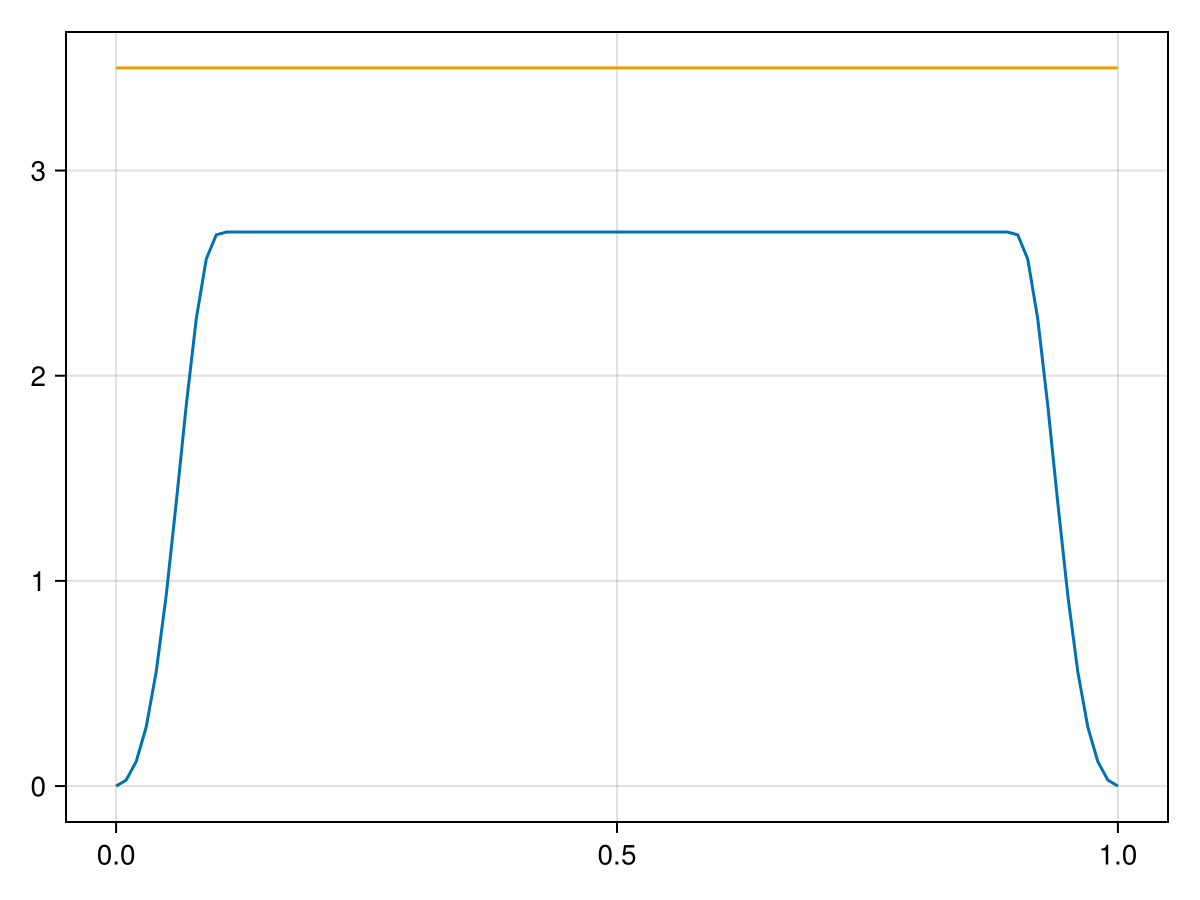

CairoMakie.Screen{IMAGE}


In [521]:
using CairoMakie
using QuantumPropagators.Controls: discretize

"""
Plot the given complex pulse in two panels: absolute value and phase.

```julia
fig = plot_complex_pulse(tlist, Ω; time_unit=:ns, ampl_unit=:(2π⋅MHz), kwargs...)
```

generates a plot of the complex field `Ω` over the time grid `tlist`.

Arguments:

* `tlist`: A vector of time grid values
* `Ω`: A complex vector of the same length as `tlist` or a function `Ω(t)` returning a complex number
* `time_unit`: A symbol that evaluates to the conversion factor for the time unit
* `ampl_unit`: A symbol that evaluates to the conversion factor of the amplitude unit

All other keyword arguments are forwarded to `Plots.plot`.
```
"""
function plot_pulses(tlist, p1, p2; time_unit=:μs, ampl_unit=:MHz, kwargs...)

    p1 = discretize(p1, tlist)  # make sure Ω is defined on *points* of `tlist`
    p2 = discretize(p2, tlist)  # make sure Ω is defined on *points* of `tlist`

    s_ampl_unit = string(ampl_unit)
    if startswith(s_ampl_unit, "")
        s_ampl_unit = s_ampl_unit[1:end]
    end

    fig = Figure()
    ax = Axis(fig[1,1])

    lines!(
        ax,
        tlist ./ eval(time_unit),
        abs.(p1) ./ eval(ampl_unit);
    )

    lines!(
        ax,
        tlist ./ eval(time_unit),
        abs.(p2) ./ eval(ampl_unit);
    )

    display(fig)

end

const 𝕚 = 1im

plot_pulses(tlist, t->Ω_guess(t), t->Δ_guess(t))

Make Hamiltonian, this is not ours.

In [522]:
import QuantumPropagators: hamiltonian
using StaticArrays: SMatrix

"""Construct the time-dependent Hamiltonian for a two-qubit transmon system.

```julia
Ĥ = transmon_hamiltonian(; δ₁, δ₂, J, Ω_re, Ω_im)
```

constructs a [Generator](@extref `QuantumPropagators.Generators.Generator`) for
a two-transmon system truncated to two levels for each qubit, in the rotating
wave approximation (RWA)

Arguments:

* `δ₁`: The detuning of qubit 1 from the RWA angular frequency
* `δ₂`: The detuning of qubit 2 from the RWA angular frequency
* `J`: The static coupling between the two qubits, as angular frequency
* `Ω_re`: The amplitude (angular frequency) of the real part of the microwave drive
* `Ω_im`: The amplitude (angular frequency) of the imaginary part of the microwave drive

Both `Ω_re` and `Ω_im` can be given as a function `Ω_re(t)` and `Ω_im(t)`, or as a
vector of values on the time grid, or on the intervals of the time grid.
"""
function transmon_hamiltonian(; Ω, Δ)


    H_Ω = (1/2) * SMatrix{4,4,ComplexF64}(
        [0      1       0           0
         1      0       0           0
         0      0       0           sqrt(2)
         0      0       sqrt(2)     0]
    )

    H_Δ = SMatrix{4,4,ComplexF64}(
        [0       0      0     0
         0       -1      0     0
         0       0      0     0
         0       0      0     -1]
    )

    return hamiltonian((H_Ω, Ω), (H_Δ, Δ))

end

transmon_hamiltonian

In [523]:
H = transmon_hamiltonian(;
    Ω = Ω_guess,
    Δ = Δ_guess,
)

Generator with 2 ops and 2 amplitudes
 ops::Vector{SMatrix{4, 4, ComplexF64, 16}}:
  ComplexF64[0.0 + 0.0im 0.5 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.5 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.7071067811865476 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.7071067811865476 + 0.0im 0.0 + 0.0im]
  ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im -1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im -1.0 + 0.0im]
 amplitudes::Vector{QuantumPropagators.Amplitudes.ShapedContinuousAmplitude}:
  ShapedAmplitude(::typeof(ϵ_Ω_guess); shape::typeof(Ω_shape))
  ShapedAmplitude(::typeof(ϵ_Δ_guess); shape::typeof(Δ_shape))


In [524]:
target_states = [
    SVector{4}(ComplexF64[1, 0, 0, 0]),  # |01⟩ → |01⟩
    # SVector{4}(ComplexF64[0, 1, 0, 0]),  # no pop ends here
    SVector{4}(ComplexF64[0, 0, 𝕚, 0]),  # |11⟩ → 𝕚|11⟩
    # SVector{4}(ComplexF64[0, 0, 0, 1]),  # no pop ends here
];


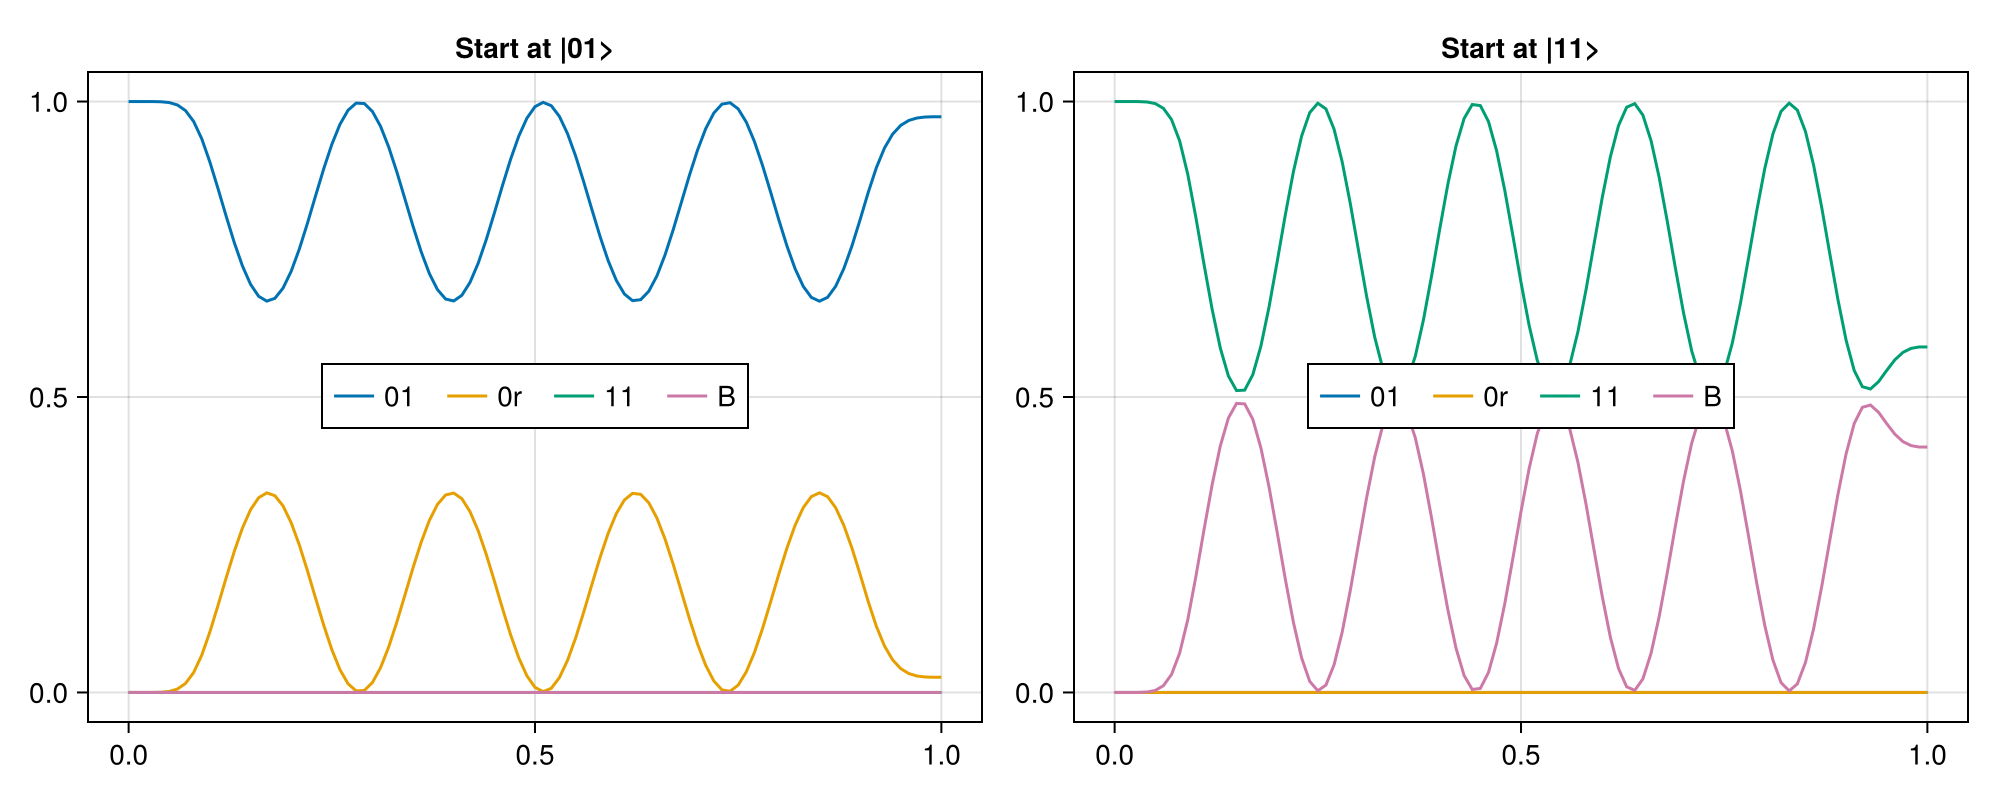

CairoMakie.Screen{IMAGE}


In [525]:
using CairoMakie
pops_01 = propagate(
    basis[1], H, tlist; method=Cheby, storage=true, observables=(Ψ -> Array(Ψ), )
)
pops_11 = propagate(
    basis[2], H, tlist; method=Cheby, storage=true, observables=(Ψ -> Array(Ψ), )
)
pops = [pops_01, pops_11] 

fig = Figure(size=(1000, 400))
for (p, title) in enumerate(["Start at |01>" "Start at |11>"])
    ax = Axis(fig[1,p], title=title)
    labels = ["01" "0r" "11" "B"]


    for (i, lab) in enumerate(labels)
        lines!(ax, tlist ./ μs, abs2.((pops[p])[i, :]), label=labels[i])
    end

    axislegend(ax, position = :cc, orientation = :horizontal)

end
display(fig)

Now define cost function, which is infidelity:

In [526]:
using LinearAlgebra

# function infidelity_CZ(Ψ, trajectories)
#     N = 2
#     # f = zero(ComplexF64)
#     ϕ_01 = angle((Ψ[1])[1])
#     ϕ_11 = angle((Ψ[3])[3])
#     f = abs(Ψ[1][1]) + cis(2ϕ_01 - ϕ_11 - π)*abs(Ψ[3][3])
#     println(cis(2ϕ_01 - ϕ_11 - π))
#     return 1.0 - (abs2(f) / N^2)
# end

function J_T_sm(Ψ, trajectories)
    N = length(basis)
    f = zero(ComplexF64)
    for (Ψ_k, traj) in zip(Ψ, trajectories)
        f += Ψ_k ⋅ traj.target_state
    end
    return 1.0 - (abs2(f) / N^2)
end

J_T_sm (generic function with 1 method)

In [527]:
using GRAPE: Trajectory

trajectories = [
    Trajectory(Ψ, H; target_state=Ψ_tgt)
    for (Ψ, Ψ_tgt) in zip(basis, target_states)
]

using QuantumPropagators.Controls: get_controls


import Zygote
using GRAPE

GRAPE.set_default_ad_framework(Zygote)

get_controls(trajectories)



┌ Info: QuantumControl: Setting Zygote as the default provider for automatic differentiation.
└ @ QuantumControl.Functionals /home/trlarkin/.julia/packages/QuantumControl/6f2PZ/src/functionals.jl:345


(Main.ϵ_Ω_guess, Main.ϵ_Δ_guess)

Now run GrAPE

In [528]:
result = GRAPE.optimize(
    trajectories,
    tlist;
    prop_method = Cheby,
    J_T = J_T_sm,
    callback = GRAPE.make_grape_print_iters(),
    iter_stop = 200,
    check_convergence = (res -> ((res.J_T < 1e-9) && "Gate error < 10⁻⁶")),
    upper_bound = 3.5MHz,
    lower_bound = 0MHz,
    use_threads = true,
)


┌ Info: make_chi for J_T=J_T_sm: fallback to mode=:automatic
└ @ QuantumControl.Functionals /home/trlarkin/.julia/packages/QuantumControl/6f2PZ/src/functionals.jl:258
┌ Info: make_chi for J_T=J_T_sm: automatic with Zygote
└ @ QuantumControl.Functionals /home/trlarkin/.julia/packages/QuantumControl/6f2PZ/src/functionals.jl:333


 iter.        J_T       ǁ∇Jǁ       ǁΔϵǁ         ΔJ   FG(F)    secs
     0   9.30e-01   1.01e-02        n/a        n/a    1(0)     1.2
     1   9.30e-01   1.01e-02   9.27e-03  -8.60e-05    1(0)     0.0
     2   5.55e-01   1.02e-02   2.73e+01  -3.74e-01    7(0)     0.4
     3   5.13e-01   1.96e-02   2.22e+00  -4.22e-02    5(0)     0.1
     4   5.03e-01   1.99e-02   5.37e-01  -1.02e-02    4(0)     1.3
     5   4.92e-01   2.00e-02   6.18e-01  -1.16e-02    4(0)     0.0
     6   4.79e-01   2.01e-02   6.91e-01  -1.28e-02    4(0)     0.0
     7   4.47e-01   2.01e-02   1.76e+00  -3.21e-02    5(0)     0.1
     8   2.53e-01   2.03e-02   1.27e+01  -1.94e-01    1(0)     0.0
     9   1.66e-01   2.09e-02   1.34e+01  -8.65e-02    1(0)     0.0
    10   1.28e-01   2.44e-02   5.54e+00  -3.87e-02    1(0)     0.0
    11   4.56e-02   2.21e-02   1.38e+01  -8.20e-02    1(0)     0.0
    12   1.30e-02   1.23e-02   1.12e+01  -3.26e-02    1(0)     0.0
    13   4.32e-03   6.27e-03   6.31e+00  -8.67e-03    1(0)    

GRAPE Optimization Result
-------------------------
- Started at 2026-04-27T15:21:36.989
- Number of trajectories: 2
- Number of iterations: 23
- Number of pure func evals: 0
- Number of func/grad evals: 47
- Value of functional: 3.04423e-13
- Reason for termination: Gate error < 10⁻⁶
- Ended at 2026-04-27T15:21:40.380 (3 seconds, 391 milliseconds)


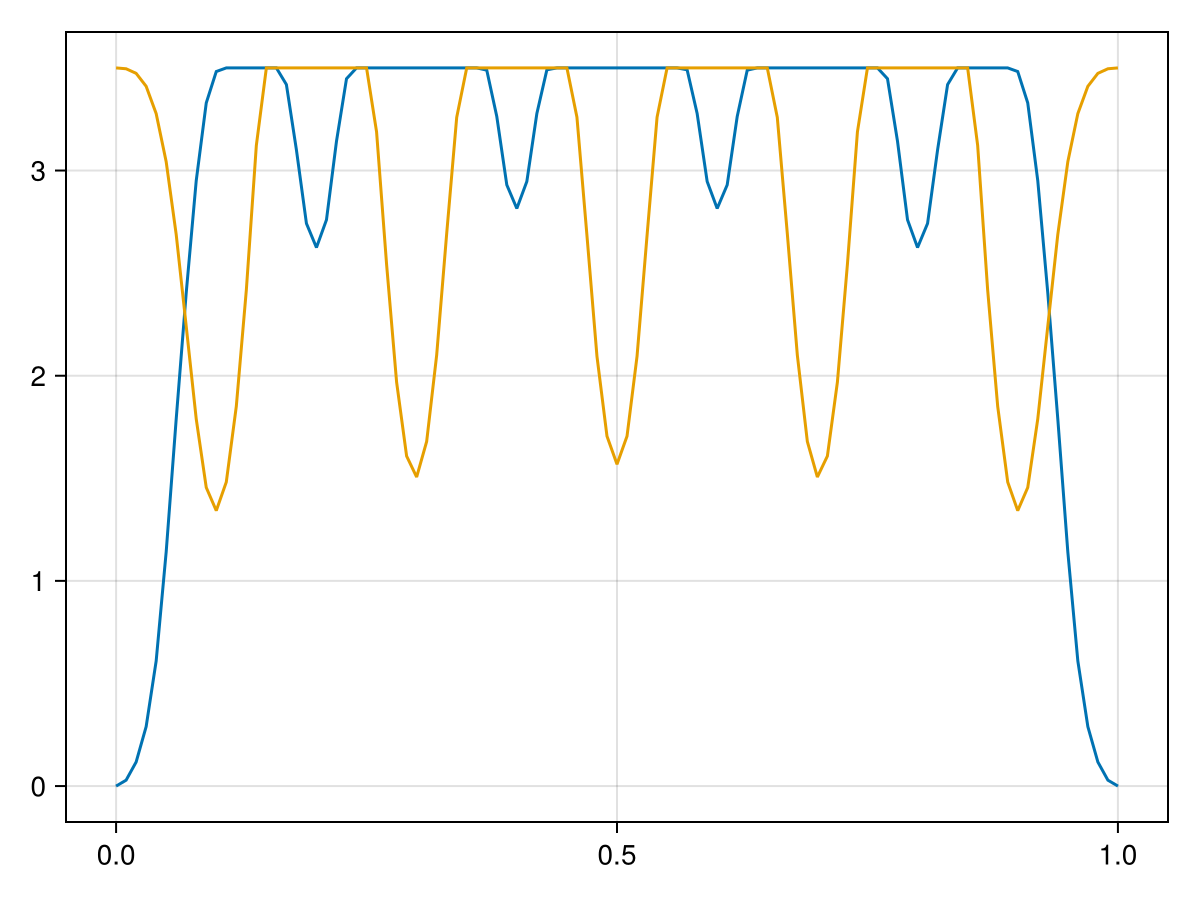

CairoMakie.Screen{IMAGE}


In [529]:
using QuantumPropagators: propagate, Cheby

ϵ_Ω_opt = result.optimized_controls[1]
ϵ_Δ_opt = result.optimized_controls[2]


# Ω_guess = ShapedAmplitude(ϵ_Ω_guess; shape=Ω_shape);
# Δ_guess = ShapedAmplitude(ϵ_Δ_guess; shape=Δ_shape);

Ω_opt = ϵ_Ω_opt .* discretize(Ω_guess.shape, tlist)
Δ_opt = ϵ_Δ_opt .* discretize(Δ_guess.shape, tlist)

plot_pulses(tlist, Ω_opt, Δ_opt)


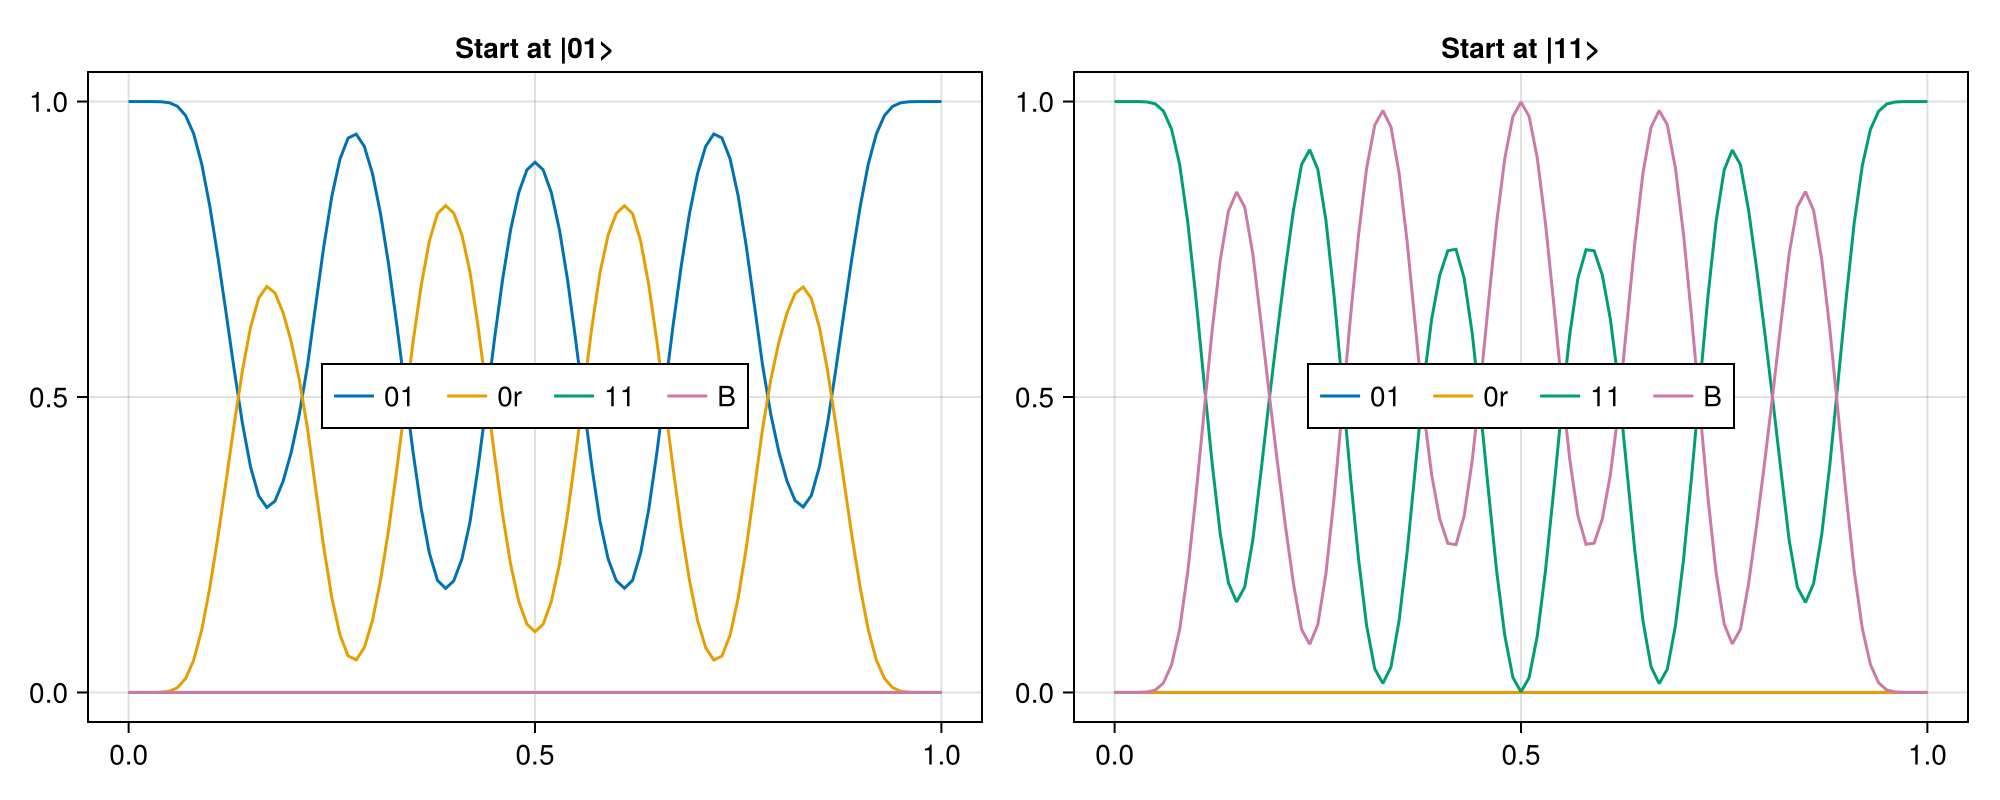

Angle:  1.119368185122397
infidelity:  0.9499125904159417


In [530]:
using CairoMakie
H_opt = transmon_hamiltonian(Ω=Ω_opt, Δ=Δ_opt)

pops_01 = propagate(
    basis[1], H_opt, tlist; method=Cheby, storage=true, observables=(Ψ -> Array(Ψ), )
)
pops_11 = propagate(
    basis[2], H_opt, tlist; method=Cheby, storage=true, observables=(Ψ -> Array(Ψ), )
)
pops = [pops_01, pops_11] 

fig = Figure(size=(1000, 400))
for (p, title) in enumerate(["Start at |01>" "Start at |11>"])
    ax = Axis(fig[1,p], title=title)
    labels = ["01" "0r" "11" "B"]


    for (i, lab) in enumerate(labels)
        lines!(ax, tlist ./ μs, abs2.((pops[p])[i, :]), label=labels[i])
    end

    axislegend(ax, position = :cc, orientation = :horizontal)

end
display(fig)

ϕ_01 = angle(pops_01[1, end])
ϕ_11 = angle(pops_11[3, end])

println("Angle:  ", (2ϕ_01 - ϕ_11) % 2π)


f = abs(pops_01[1, end]) + cis(2ϕ_01 - ϕ_11 + π/2)*abs(pops_11[3, end])
println("infidelity:  ", 1.0 - (abs2(f) / 4))

In [531]:
println(Ω_opt)
println(Δ_opt)

[-2.3543112361558264e-16, 0.18141122398208054, 0.7370871792408377, 1.819998076220323, 3.830715710907785, 7.171040542488101, 11.238633006498953, 15.10270519277254, 18.539412098688704, 20.91858279491523, 21.88040875545637, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.48115748540095, 19.480904406000853, 17.228057784366733, 16.49044234890561, 17.33985332782523, 19.7461096466807, 21.659536379122805, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.92226297064861, 20.504666293375156, 18.408888675547836, 17.686409585812566, 18.513527219902905, 20.59458331165091, 21.932128899867834, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991

In [ ]:
[-2.3543112361558264e-16, 0.18141122398208054, 0.7370871792408377, 1.819998076220323, 3.830715710907785, 7.171040542488101, 11.238633006498953, 15.10270519277254, 18.539412098688704, 20.91858279491523, 21.88040875545637, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.48115748540095, 19.480904406000853, 17.228057784366733, 16.49044234890561, 17.33985332782523, 19.7461096466807, 21.659536379122805, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.92226297064861, 20.504666293375156, 18.408888675547836, 17.686409585812566, 18.513527219902905, 20.59458331165091, 21.932128899867834, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.932128899867777, 20.594583311650524, 18.513527219902393, 17.686409585812356, 18.40888867554802, 20.50466629337543, 21.922262970648667, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.659536379122983, 19.74610964668103, 17.339853327825523, 16.490442348905766, 17.22805778436674, 19.480904406000846, 21.48115748540095, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.88040875545637, 20.91858279491523, 18.5394120986887, 15.102705192772527, 11.238633006498954, 7.171040542488187, 3.8307157109078536, 1.8199980762203414, 0.7370871792408419, 0.18141122398208168, -2.3543112361558264e-16]
[21.991148575128552, 21.96471791619144, 21.824668963535892, 21.428377546759975, 20.591847470128855, 19.117477275205058, 16.89054264088027, 14.078190858964325, 11.239776818068279, 9.142883826701588, 8.434132639169025, 9.309351691359149, 11.627814750678416, 15.186743485231865, 19.618959317952662, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 20.03482671887091, 15.976935988926819, 12.369355085674915, 10.104883275319358, 9.463348955217803, 10.550979946267905, 13.197711944654735, 16.91940909176784, 20.478114172992107, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 20.484141523782736, 16.85995994072831, 13.159007656194689, 10.714697699138123, 9.854165494906677, 10.714697699138537, 13.159007656195495, 16.85995994072937, 20.484141523783297, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 20.478114172991894, 16.91940909176737, 13.197711944654312, 10.550979946267617, 9.46334895521769, 10.104883275319462, 12.369355085675235, 15.97693598892386, 20.03482671886773, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 19.61895931795308, 15.186743485232654, 11.627814750679015, 9.30935169135943, 8.434132639168997, 9.142883826701402, 11.239776818068064, 14.078190858964085, 16.890542640880064, 19.117477275204926, 20.591847470128762, 21.428377546759943, 21.824668963535892, 21.96471791619144, 21.991148575128552]

101-element Vector{Float64}:
 0.0
 0.060703321513925365
 0.3872828151368254
 1.2630192775739753
 2.7703275657977877
 4.539972880719997
 6.03686795825432
 7.010021335793025
 7.447778835380577
 7.403880972190105
 ⋮
 7.447778835380575
 7.010021335793007
 6.036867958254302
 4.539972880719983
 2.7703275657977784
 1.2630192775739713
 0.38728281513682455
 0.06070332151392521
 0.0